In [ ]:
import nltk

# دانلود کلمات توقف (stopwords)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')
import pandas as pd
import numpy as np
import json
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from datetime import datetime


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
# Download dataset from Kaggle and load it into the environment
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Load the JSON file into a DataFrame
with open('/content/kaggle.json', 'r') as file:
    data = json.load(file)

# Download the dataset from Kaggle
!kaggle datasets download -d beridzeg45/guardian-environment-related-news

# Extract the dataset
import zipfile
with zipfile.ZipFile('guardian-environment-related-news.zip', 'r') as zip_ref:
    zip_ref.extractall('guardian-environment-related-news')

df=pd.read_csv('/content/guardian-environment-related-news/guardian_environment_news.csv')
df.head()


mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/beridzeg45/guardian-environment-related-news
License(s): other
guardian-environment-related-news.zip: Skipping, found more recently modified local copy (use --force to force download)


,Title,Intro Text,Authors,Article Text,Date Published
0,Liz Truss ‘will approve more oil drilling if ...,Tory leadership candidate criticised by campai...,"['Rob Davies', '@ByRobDavies']",Liz Truss will sign off on a push for more oil...,2022-08-30
1,Renewed Highland golf course plan has environm...,Scottish government rejected a new links at Co...,"['Ewan Murray', '@mrewanmurray']",It is an area so tranquil that the notion of b...,2021-03-22
2,Visiting green spaces deters mental health dr...,Positive effects were stronger among those rep...,"['Damien Gayle', '@damiengayle']","Visits to parks, community gardens and other u...",2023-01-17
3,Bought too much red cabbage? Turn it into a fe...,This fantastic vegan centrepiece makes full us...,['Tom Hunt'],"I devised today’s nut roast for Oddbox, a veg ...",2023-12-22
4,‘This year has been very good’: readers’ UK bu...,Readers share their favourite sightings over t...,['Guardian readers'],‘Constant companions to our gardening’A peacoc...,2023-12-19


In [ ]:
import re
import string

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'\[.*?\]', '', text)  # حذف محتوای داخل براکت‌ها
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # حذف علائم نگارشی
    text = re.sub(r'\w*\d\w*', '', text)  # حذف کلماتی که شامل اعداد هستند
    text = text.lower()  # تبدیل متن به حروف کوچک
    text = re.sub(r'\s+', ' ', text).strip()  # حذف فاصله‌های اضافی
    return text

# اعمال تابع به ستون 'Article Text'
df['cleaned_text'] = df['Article Text'].apply(lambda x: clean_text(x))


In [ ]:
stop_words = set(stopwords.words('english'))

def tokenize_and_remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens

df['tokens'] = df['cleaned_text'].apply(lambda x: tokenize_and_remove_stopwords(x))


In [ ]:
df['Date Published'] = pd.to_datetime(df['Date Published'])
df['year'] = df['Date Published'].dt.year


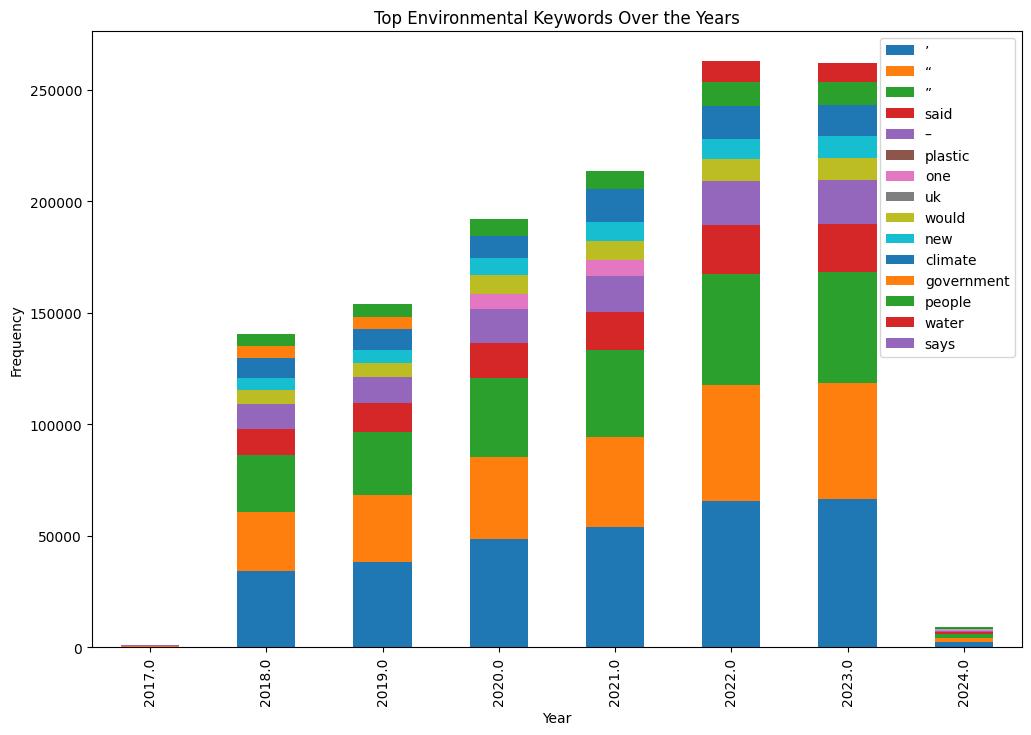

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# تابع برای استخراج کلمات کلیدی برتر
def get_top_keywords(tokens, top_n=10):
    return dict(Counter(tokens).most_common(top_n))

# تجمیع توکن‌ها بر اساس سال
df_yearly = df.groupby('year')['tokens'].apply(lambda x: [item for sublist in x for item in sublist])

# استخراج کلمات کلیدی برتر برای هر سال
df_yearly_top_keywords = df_yearly.apply(lambda x: get_top_keywords(x))

# تبدیل دیکشنری‌ها به DataFrame
df_keywords = pd.DataFrame(list(df_yearly_top_keywords.items()), columns=['year', 'keywords'])

# تغییر شکل داده‌ها برای رسم
df_keywords_expanded = df_keywords.set_index('year')['keywords'].apply(pd.Series).fillna(0).astype(int)

# رسم نمودار
df_keywords_expanded.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Top Environmental Keywords Over the Years')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()


In [ ]:
sia = SentimentIntensityAnalyzer()

df['sentiment'] = df['cleaned_text'].apply(lambda x: sia.polarity_scores(x))
df['sentiment_compound'] = df['sentiment'].apply(lambda x: x['compound'])

# Determine sentiment category
df['sentiment_category'] = df['sentiment_compound'].apply(lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral'))


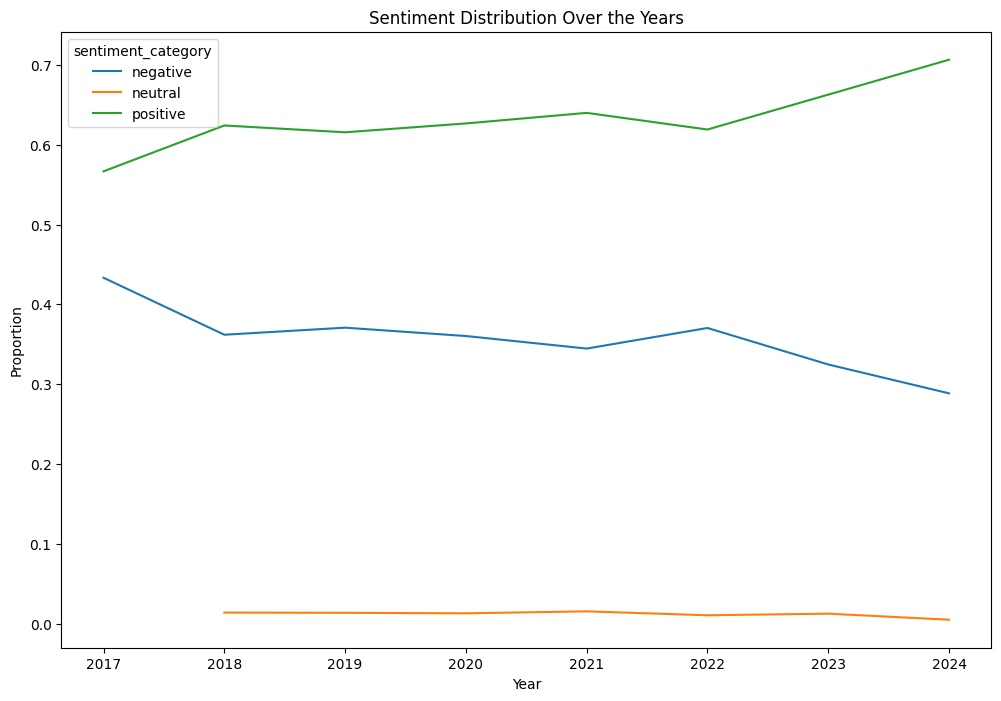

In [ ]:
sentiment_by_year = df.groupby('year')['sentiment_category'].value_counts(normalize=True).unstack()

sentiment_by_year.plot(kind='line', figsize=(12, 8))
plt.title('Sentiment Distribution Over the Years')
plt.xlabel('Year')
plt.ylabel('Proportion')
plt.show()


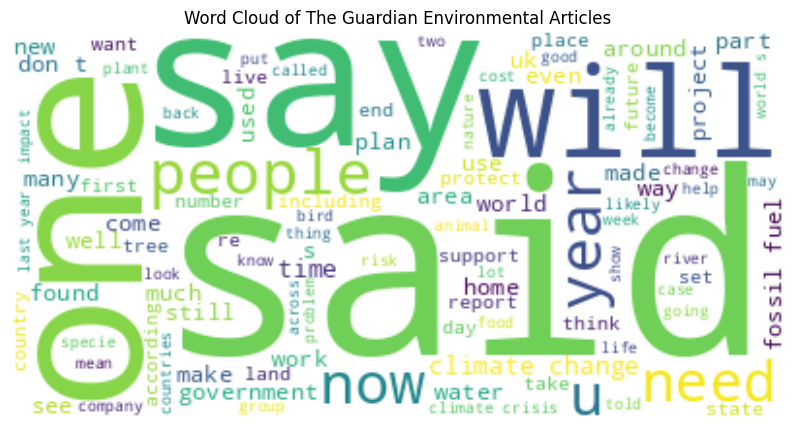

In [ ]:
text = ' '.join(df['cleaned_text'].values)
wordcloud = WordCloud(max_words=100, background_color='white').generate(text)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of The Guardian Environmental Articles')
plt.show()
